In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from collections import defaultdict
import os

# Resolve paths relative to this notebook's directory
_NOTEBOOK_DIR = os.path.dirname(os.path.abspath('mooncake-plot.ipynb'))
NUM_TOKEN_PER_HASH_ID = 50

def load_mooncake_data(input_file):
    # If the path is already absolute, use it as-is; otherwise resolve relative to notebook dir
    if os.path.isabs(input_file):
        filepath = input_file
    else:
        filepath = os.path.join(_NOTEBOOK_DIR, input_file)
    data = []
    with open(filepath, 'r') as f:
        for line in f:
            data.append(json.loads(line.strip()))

    # Convert to DataFrame for easier analysis
    df = pd.DataFrame(data)

    # Convert timestamp from milliseconds to seconds
    df['timestamp_seconds'] = df['timestamp'] / 1000

    print(f"Dataset info:")
    print(f"Total requests: {len(df)}")

    # Compute block-derived input length (used in distribution and time series plots)
    df['num_token_blocks'] = df['hash_ids'].apply(len)
    df['input_length_from_blocks'] = df['num_token_blocks'] * NUM_TOKEN_PER_HASH_ID

    # Create distribution plots
    fig, axes = plt.subplots(2, 2, figsize=(10, 6))
    workload_name = os.path.basename(input_file).split('.')[0]
    fig.suptitle(f'{workload_name} - Distribution Analysis', fontsize=16)

    # 1. RPS calculation and distribution
    # Group by second and count requests
    rps_data = df.groupby(df['timestamp_seconds'].astype(int)).size()
    print(f"RPS stats: min={rps_data.min()}, max={rps_data.max()}, mean={rps_data.mean():.2f}, std={rps_data.std():.2f}")

    # RPS distribution
    axes[0, 0].hist(rps_data.values, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0, 0].set_xlabel('Requests per Second')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('RPS Distribution')
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Input token length distribution (derived from hash_id blocks)
    axes[0, 1].hist(df['input_length_from_blocks'], bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
    axes[0, 1].set_xlabel('Input Token Length (from blocks)')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Input Token Length Distribution (from blocks)')
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Output token length distribution
    axes[1, 0].hist(df['output_length'], bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
    axes[1, 0].set_xlabel('Output Token Length')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Output Token Length Distribution')
    axes[1, 0].grid(True, alpha=0.3)

    # 4. Scatter plot of input vs output length
    axes[1, 1].scatter(df['input_length'], df['output_length'], alpha=0.5, s=20, c='purple')
    axes[1, 1].set_xlabel('Input Token Length')
    axes[1, 1].set_ylabel('Output Token Length')
    axes[1, 1].set_title('Input vs Output Token Length')
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    

    ####################################################################################################################################################################################
    ####################################################################################################################################################################################
    ####################################################################################################################################################################################
    
    # Create time series plots (1 second granularity) and token block distribution
    fig, axes = plt.subplots(3, 2, figsize=(10, 6))
    fig.suptitle(f'{workload_name} - Time Series Analysis (1 second granularity)', fontsize=16)

    # Prepare time series data
    max_time = int(df['timestamp_seconds'].max()) + 1
    time_bins = range(0, max_time + 1)

    # 1. RPS over time
    rps_by_second = df.groupby(df['timestamp_seconds'].astype(int)).size().reindex(time_bins, fill_value=0)

    axes[0, 0].plot(rps_by_second.index, rps_by_second.values, linewidth=1, alpha=0.8, color='blue')
    axes[0, 0].set_xlabel('Time (seconds)')
    axes[0, 0].set_ylabel('Requests per Second')
    axes[0, 0].set_title('RPS Over Time')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].set_xlim(0, max_time)

    # 2. Average input token length over time
    input_tokens_by_second = df.groupby(df['timestamp_seconds'].astype(int))['input_length'].mean().reindex(time_bins, fill_value=np.nan)

    # Only plot points where we have data (non-NaN values)
    valid_input_mask = ~input_tokens_by_second.isna()
    axes[0, 1].plot(input_tokens_by_second.index[valid_input_mask], input_tokens_by_second.values[valid_input_mask], linewidth=1, alpha=0.8, color='green')
    axes[0, 1].set_xlabel('Time (seconds)')
    axes[0, 1].set_ylabel('Average Input Token Length')
    axes[0, 1].set_title('Average Input Token Length Over Time')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_xlim(0, max_time)

    # 3. Average output token length over time
    output_tokens_by_second = df.groupby(df['timestamp_seconds'].astype(int))['output_length'].mean().reindex(time_bins, fill_value=np.nan)

    # Only plot points where we have data (non-NaN values)
    valid_output_mask = ~output_tokens_by_second.isna()
    axes[1, 0].plot(output_tokens_by_second.index[valid_output_mask], output_tokens_by_second.values[valid_output_mask], linewidth=1, alpha=0.8, color='red')
    axes[1, 0].set_xlabel('Time (seconds)')
    axes[1, 0].set_ylabel('Average Output Token Length')
    axes[1, 0].set_title('Average Output Token Length Over Time')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_xlim(0, max_time)

    # 4. Per-request prefix cache hit ratio over time (trie-based, temporal order)
    class _TrieNode:
        __slots__ = ['children']
        def __init__(self):
            self.children = {}

    def compute_prefix_hit_ratios_trie(df_sorted):
        root = _TrieNode()
        hit_ratios = []
        timestamps = []
        for _, row in df_sorted.iterrows():
            hids = row['hash_ids']
            total_blocks = len(hids)
            node = root
            matched = 0
            for h in hids:
                if h in node.children:
                    matched += 1
                    node = node.children[h]
                else:
                    break
            hit_ratios.append(matched / total_blocks if total_blocks > 0 else 0.0)
            timestamps.append(row['timestamp_seconds'])
            node = root
            for h in hids:
                if h not in node.children:
                    node.children[h] = _TrieNode()
                node = node.children[h]
        return timestamps, hit_ratios

    df_sorted_by_time = df.sort_values('timestamp_seconds').reset_index(drop=True)
    hit_ts, hit_ratios = compute_prefix_hit_ratios_trie(df_sorted_by_time)

    axes[1, 1].scatter(hit_ts, hit_ratios, alpha=0.15, s=8, color='purple', label='per-request hit ratio')

    # 10-second sliding window average
    window_s = 10
    hit_ts_arr = np.array(hit_ts)
    hit_ratios_arr = np.array(hit_ratios)
    sw_x, sw_y = [], []
    for i, t in enumerate(hit_ts_arr):
        mask = (hit_ts_arr >= t - window_s) & (hit_ts_arr <= t)
        sw_x.append(t)
        sw_y.append(hit_ratios_arr[mask].mean())
    axes[1, 1].plot(sw_x, sw_y, color='red', linewidth=1.5, alpha=0.9, label=f'{window_s}s sliding avg')
    axes[1, 1].set_xlabel('Time (seconds)')
    axes[1, 1].set_ylabel('Prefix Cache Hit Ratio')
    axes[1, 1].set_title('Prefix Cache Hit Ratio Over Time (per request)')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].set_xlim(0, max_time)
    axes[1, 1].set_ylim(0, 1)
    axes[1, 1].legend(fontsize=10)

    # 5. Token blocks per request distribution
    axes[2, 0].hist(df['num_token_blocks'], bins=30, alpha=0.7, color='orange', edgecolor='black')
    axes[2, 0].set_xlabel('Number of Token Blocks')
    axes[2, 0].set_ylabel('Frequency')
    axes[2, 0].set_title('Token Blocks per Request Distribution')
    axes[2, 0].grid(True, alpha=0.3)

    # Hide the empty subplot
    axes[2, 1].set_visible(False)

    plt.tight_layout()
    plt.show()

Dataset info:
Total requests: 12031
RPS stats: min=2, max=28, mean=10.20, std=3.35


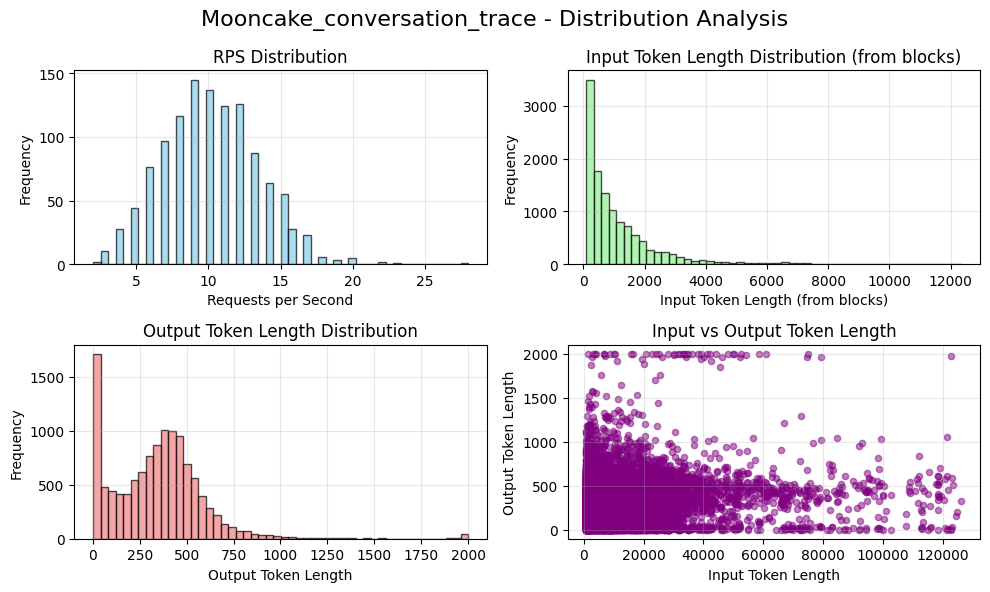

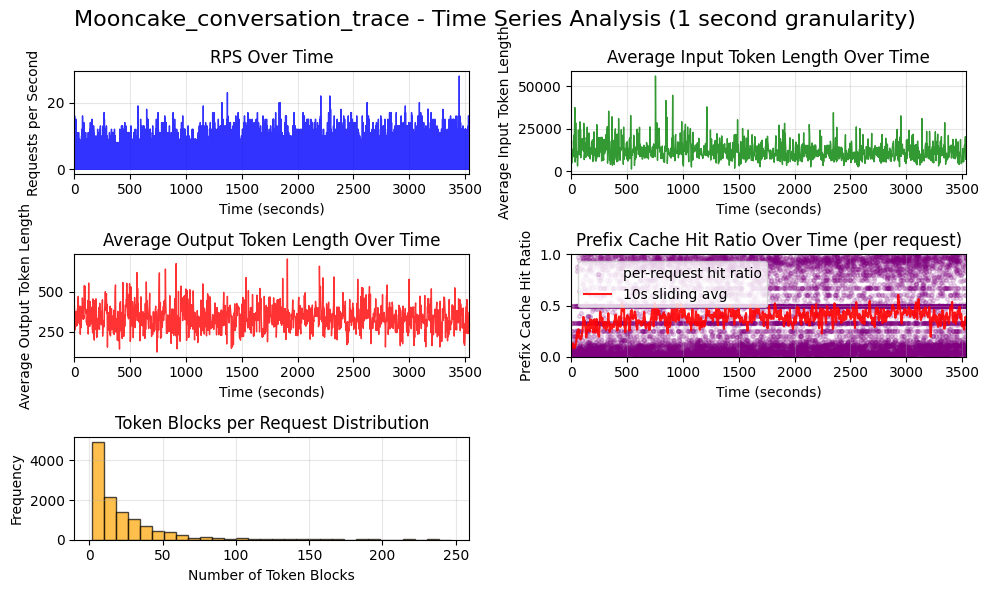

Dataset info:
Total requests: 23608
RPS stats: min=5, max=47, mean=20.01, std=5.61


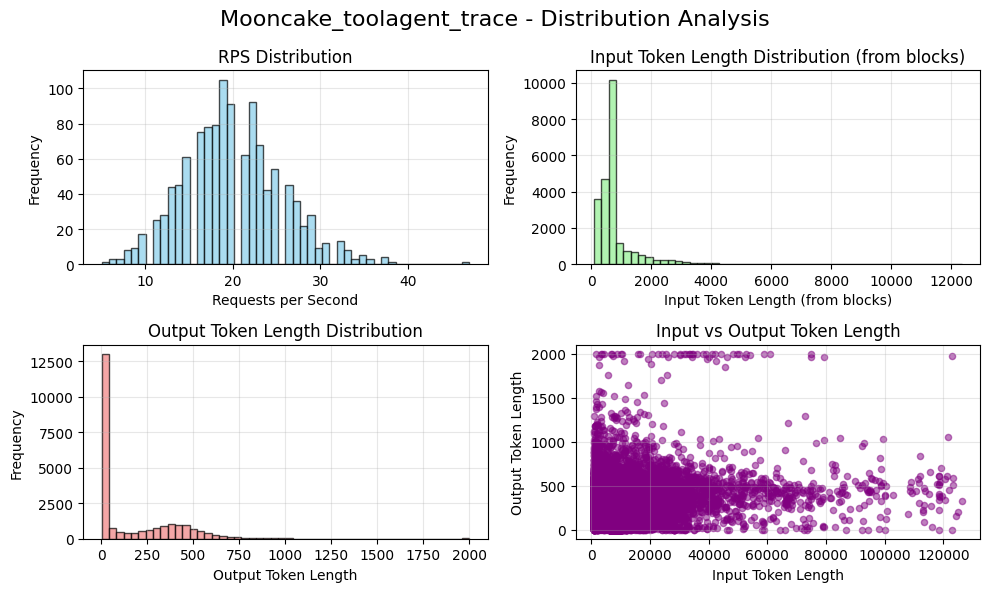

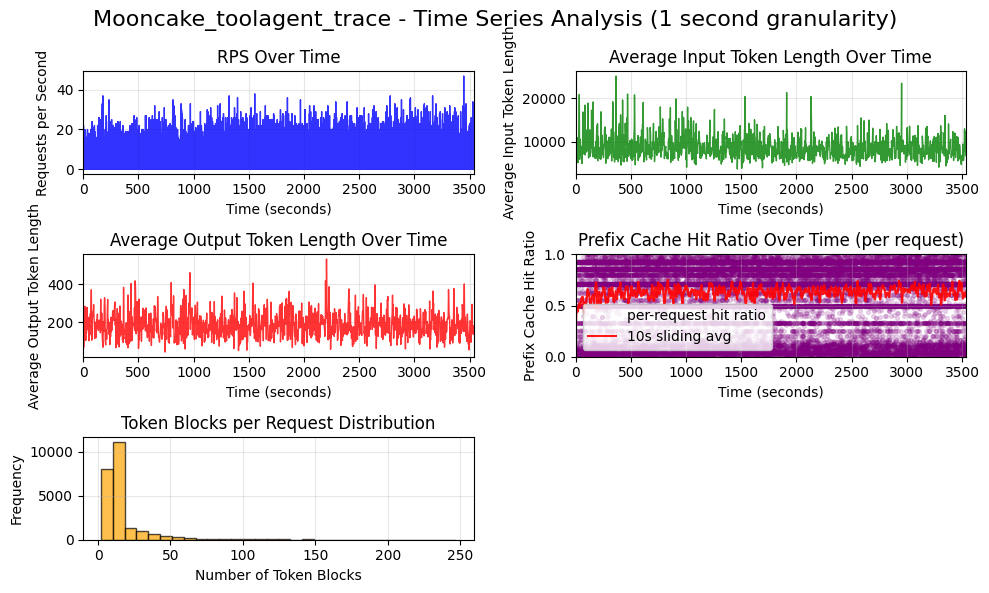

Dataset info:
Total requests: 3993
RPS stats: min=1, max=13, mean=4.02, std=1.98


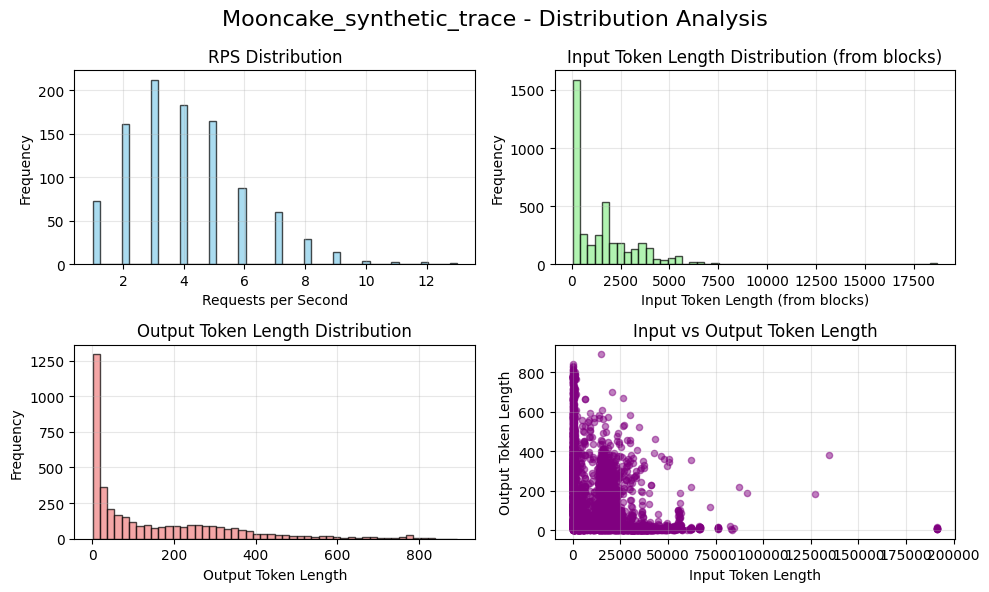

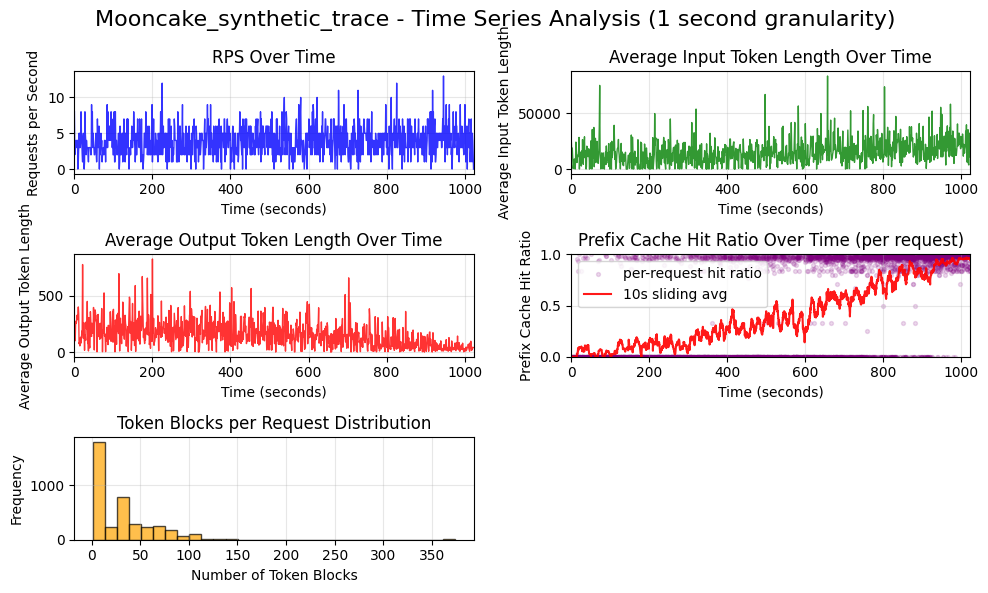

In [2]:
load_mooncake_data('/mnt/projects/aibrix-gangmuk-fixing/benchmarks/data-driven-routing/routing-agent-service/workload-and-experiment_results/workload-generator/mooncake/Mooncake_conversation_trace.jsonl')
load_mooncake_data('/mnt/projects/aibrix-gangmuk-fixing/benchmarks/data-driven-routing/routing-agent-service/workload-and-experiment_results/workload-generator/mooncake/Mooncake_toolagent_trace.jsonl')
load_mooncake_data('/mnt/projects/aibrix-gangmuk-fixing/benchmarks/data-driven-routing/routing-agent-service/workload-and-experiment_results/workload-generator/mooncake/Mooncake_synthetic_trace.jsonl')